But final :
- indiquer si ce qui est trouvé est une calcification ou une masse
- indiquer si ce qui est trouvé dans le sein est malignant ou non
- indiquer la ou les zones dangereuses

In [1]:
import zipfile
from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [2]:
# Config path
# make sure name match
ZIP_FILENAME = "cancer.zip"

ZIP_PATH = Path(ZIP_FILENAME)
if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Could not find {ZIP_FILENAME} in your directory.")

print("Found local ZIP archive.")

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    # Read the training CSV directly out of the zip archive's 'csv/' folder a
    with z.open("csv/mass_case_description_train_set.csv") as f:
        df_mass_train = pd.read_csv(f)
    with z.open("csv/mass_case_description_test_set.csv") as f:
        df_mass_test = pd.read_csv(f)
    with z.open("csv/calc_case_description_train_set.csv") as f:
        df_calc_train = pd.read_csv(f)
    with z.open("csv/calc_case_description_test_set.csv") as f:
        df_calc_test = pd.read_csv(f)
    with z.open("csv/dicom_info.csv") as f:
        df_dicom = pd.read_csv(f)
    with z.open("csv/meta.csv") as f:
        df_meta = pd.read_csv(f)

print(f"Successfully extracted and loaded CSV from inside the ZIP.")

Found local ZIP archive.
Successfully extracted and loaded CSV from inside the ZIP.


# Mass Case Description Dataset - Column Definitions

This dataset originates from the **CBIS-DDSM (Curated Breast Imaging Subset of Digital Database for Screening Mammography)**. It is standardly utilized in medical data science and machine learning for breast cancer detection and classification tasks.

Below is a detailed breakdown of each column included in the dataset:

### 1. `patient_id`
* **Type:** String / Object
* **Description:** A unique identifier assigned to each anonymized patient (e.g., `P_00016`).
* **Note:** The same patient ID may appear across multiple rows if a patient has multiple mammograms or distinct lesions documented.

### 2. `breast_density`
* **Type:** Integer (1 to 4)
* **Description:** A numerical assessment indicating the density of the breast tissue according to standard BI-RADS guidelines:
  * **1:** Almost entirely fatty tissue (low density).
  * **2:** Scattered areas of fibroglandular density.
  * **3:** Heterogeneously dense (may obscure small findings).
  * **4:** Extremely dense (lowers the overall sensitivity of mammography).

### 3. `left or right breast`
* **Type:** String / Categorical
* **Description:** Indicates which breast is captured in the specific mammogram image.
* **Values:** `LEFT` or `RIGHT`

### 4. `image view`
* **Type:** String / Categorical
* **Description:** The radiographic orientation or angle from which the mammogram was taken:
  * **CC (Craniocaudal):** A top-down projection of the breast tissue.
  * **MLO (Mediolateral Oblique):** A side angle projection, often capturing a portion of the pectoral muscle.

### 5. `abnormality id`
* **Type:** Integer
* **Description:** An identifier used to index a specific lesion or finding within a patient's record (e.g., `1`). If a patient has multiple separate masses, they are numbered sequentially.

### 6. `abnormality type`
* **Type:** String / Categorical
* **Description:** The broad radiological category of the structural finding. In this filtered test set, the value is consistently labeled as `mass`.

### 7. `mass shape`
* **Type:** String / Categorical
* **Description:** The geometric characterization of the lesion's visual shape.
* **Common Values:** `ROUND`, `OVAL`, `LOBULATED`, or `IRREGULAR` (irregular structures typically correlate with higher clinical suspicion).

### 8. `mass margins`
* **Type:** String / Categorical (Contains null values)
* **Description:** Visual description of the border or edge of the mass. This is a critical metric for diagnostic workflows:
  * **CIRCUMSCRIBED:** Well-defined, clear boundaries (frequently benign features).
  * **ILL_DEFINED / OBSCURED:** Partially hidden or poorly delineated margins.
  * **SPICULATED:** Sharp, star-burst, or radiating lines expanding from the mass (highly suspicious for malignancy).

### 9. `assessment`
* **Type:** Integer (0 to 5)
* **Description:** The initial BI-RADS assessment score assigned by the reading radiologist:
  * **0:** Incomplete assessment (requires additional imaging evaluation).
  * **2:** Benign finding.
  * **3:** Probably benign (short-interval follow-up recommended).
  * **4:** Suspicious abnormality (biopsy recommended).
  * **5:** Highly suggestive of malignancy.

### 10. `pathology`
* **Type:** String / Categorical
* **Description:** The definitive histopathological diagnosis established via biopsy or clinical follow-up. This is typically used as the primary target/ground-truth label for predictive modeling.
* **Values:** `BENIGN`, `BENIGN_WITHOUT_CALLBACK`, or `MALIGNANT`.

In [3]:
df_mass_train

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313,P_02033,2,RIGHT,MLO,1,mass,IRREGULAR,ILL_DEFINED,3,MALIGNANT,4,Mass-Training_P_02033_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_02033_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_02033_RIGHT_MLO_1/1.3.6.1.4.1....
1314,P_02079,2,RIGHT,CC,1,mass,ROUND,SPICULATED,3,MALIGNANT,5,Mass-Training_P_02079_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_02079_RIGHT_CC_1/1.3.6.1.4.1.9...,Mass-Training_P_02079_RIGHT_CC_1/1.3.6.1.4.1.9...
1315,P_02079,2,RIGHT,MLO,1,mass,ROUND,SPICULATED,3,MALIGNANT,5,Mass-Training_P_02079_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_02079_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_02079_RIGHT_MLO_1/1.3.6.1.4.1....
1316,P_02092,2,LEFT,CC,1,mass,IRREGULAR,SPICULATED,3,MALIGNANT,2,Mass-Training_P_02092_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_02092_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_02092_LEFT_CC_1/1.3.6.1.4.1.95...


In [4]:
df_calc_train

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1541,P_02566,2,RIGHT,MLO,1,calcification,AMORPHOUS-PLEOMORPHIC,SEGMENTAL,5,MALIGNANT,5,Calc-Training_P_02566_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_02566_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_02566_RIGHT_MLO_1/1.3.6.1.4.1....
1542,P_02572,2,LEFT,CC,1,calcification,AMORPHOUS,CLUSTERED,0,MALIGNANT,2,Calc-Training_P_02572_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_02572_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_02572_LEFT_CC_1/1.3.6.1.4.1.95...
1543,P_02572,2,LEFT,MLO,1,calcification,AMORPHOUS,CLUSTERED,0,MALIGNANT,2,Calc-Training_P_02572_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_02572_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_02572_LEFT_MLO_1/1.3.6.1.4.1.9...
1544,P_02584,1,LEFT,CC,1,calcification,PLEOMORPHIC,SEGMENTAL,0,BENIGN,4,Calc-Training_P_02584_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_02584_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_02584_LEFT_CC_1/1.3.6.1.4.1.95...


In [5]:
df_dicom

,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10232,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.62798...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.627982...,NaN,8,8,BREAST,3744,20160503,134238.422,WSD,...,MATLAB,ROI mask images,1.3.6.1.4.1.9590.100.1.2.627982547125586065005...,1,0,ISO_IR 100,20170906.0,DDSM,1.3.6.1.4.1.9590.100.1.2.310901637111684385906...,91038.0
10233,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.82451...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.824512...,NaN,16,16,BREAST,3316,20160426,123905.617,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.824512568105677732346...,1,0,ISO_IR 100,20161004.0,DDSM,1.3.6.1.4.1.9590.100.1.2.246896536912401556922...,132704.0
10234,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24759...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.247594...,NaN,16,16,BREAST,2712,20160426,134551.632,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.247594800112988856209...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.150339554012064216510...,191922.0
10235,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.28513...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.285138...,NaN,8,8,BREAST,2736,20160426,110906.969,WSD,...,MATLAB,ROI mask images,1.3.6.1.4.1.9590.100.1.2.285138900913160236325...,1,0,ISO_IR 100,20160721.0,DDSM,1.3.6.1.4.1.9590.100.1.2.426769868613284096628...,83526.0


In [6]:
df_meta

,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDescription,BodyPartExamined,SeriesNumber,Collection,Visibility,ImageCount
0,1.3.6.1.4.1.9590.100.1.2.117041576511324414842...,1.3.6.1.4.1.9590.100.1.2.229361142710768138411...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
1,1.3.6.1.4.1.9590.100.1.2.438738396107617880132...,1.3.6.1.4.1.9590.100.1.2.195593486612988388325...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
2,1.3.6.1.4.1.9590.100.1.2.767416741131676463382...,1.3.6.1.4.1.9590.100.1.2.257901172612530623323...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
3,1.3.6.1.4.1.9590.100.1.2.296931352612305599800...,1.3.6.1.4.1.9590.100.1.2.109468616710242115222...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
4,1.3.6.1.4.1.9590.100.1.2.436657670120353100077...,1.3.6.1.4.1.9590.100.1.2.380627129513562450304...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
...,...,...,...,...,...,...,...,...,...
6770,1.3.6.1.4.1.9590.100.1.2.424889390711092892018...,1.3.6.1.4.1.9590.100.1.2.416082235212771925836...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
6771,1.3.6.1.4.1.9590.100.1.2.627433012114953458354...,1.3.6.1.4.1.9590.100.1.2.763083562112003848332...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,1
6772,1.3.6.1.4.1.9590.100.1.2.250048723412722873040...,1.3.6.1.4.1.9590.100.1.2.354475681612412200004...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,1
6773,1.3.6.1.4.1.9590.100.1.2.323173986211744534717...,1.3.6.1.4.1.9590.100.1.2.185043095411645186738...,MG,cropped images,BREAST,1,CBIS-DDSM,1,1


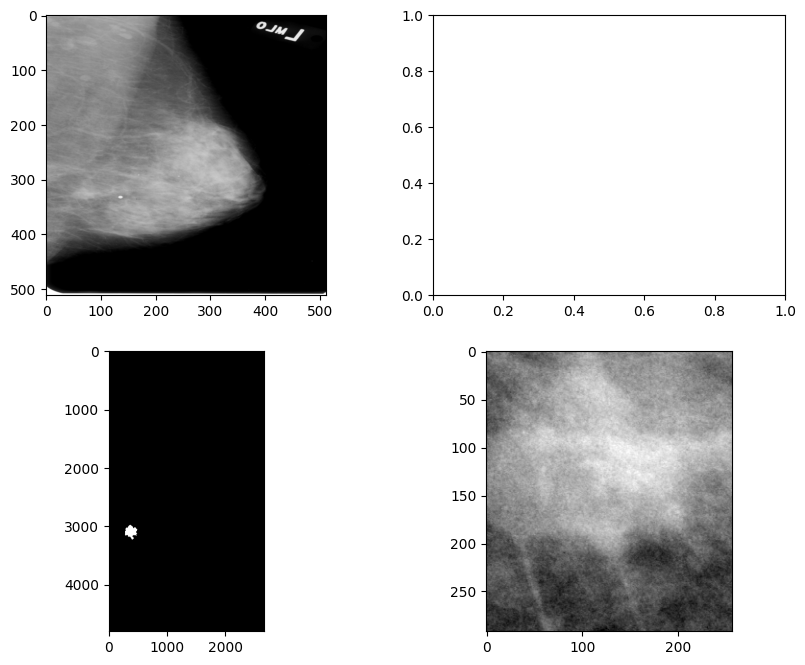

In [7]:
# image_path = patient['cropped image file path'].values[0]
#     image_path2 = patient['ROI mask file path'].values[0]
#     print(image_path)
#     print(image_path2)

def get_full_image(total_path):
    wanted_path = total_path.split('/')[2]
    folder = "jpeg/"+wanted_path

    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        all_paths = z.namelist()

        files_in_folder = [
            path for path in all_paths
            if path.startswith(folder)
        ]
        image = files_in_folder[0]
        with z.open(image) as f:
            img = Image.open(f, mode="r").convert("L").resize((512,512))
            return img

def get_roi_and_cropped(total_path):
    wanted_path = total_path.split('/')[2]
    folder = "jpeg/"+wanted_path

    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        all_paths = z.namelist()

        files_in_folder = [
            path for path in all_paths
            if path.startswith(folder)
        ]
        crop_path = files_in_folder[0]
        roi_path = files_in_folder[1]
        with z.open(crop_path) as f:
            crop = Image.open(f, mode="r").convert("L")
        with z.open(roi_path) as f:
            roi = Image.open(f, mode="r").convert("L")
        return crop, roi

patient = df_mass_train.iloc[1]
full_img = get_full_image(patient['image file path'])
crop, roi = get_roi_and_cropped(patient['ROI mask file path'])
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax[0][0].imshow(full_img, cmap='gray')
ax[1][0].imshow(roi, cmap='gray')
ax[1][1].imshow(crop, cmap='gray')

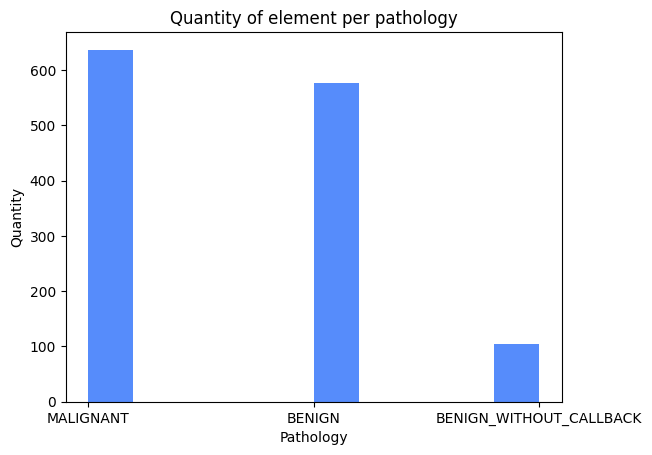

In [8]:
plt.hist(df_mass_train['pathology'])
plt.xlabel('Pathology')
plt.ylabel('Quantity')
plt.title('Quantity of element per pathology')
plt.show()

Here we can see a difference in the quantity for each class, this is a problem we need to attend to.

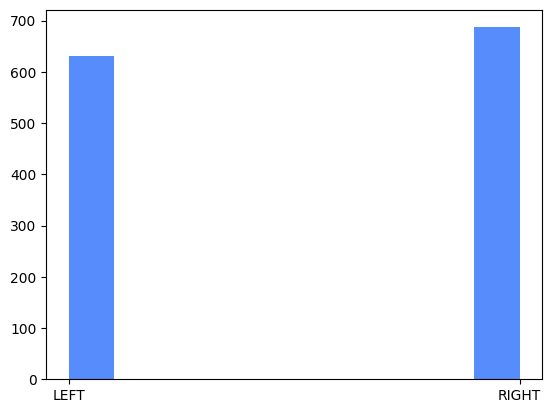

In [9]:
plt.hist(df_mass_train['left or right breast'])
plt.show()

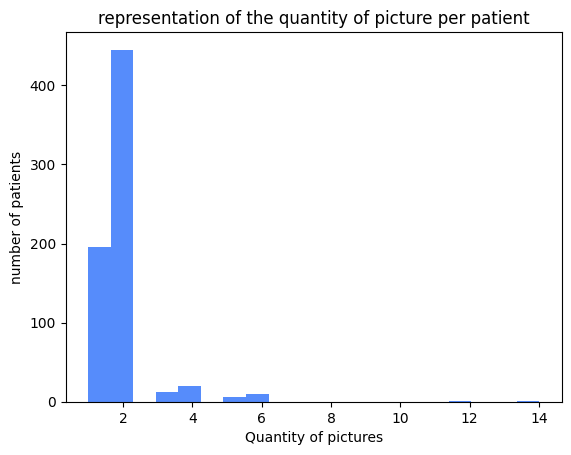

In [10]:
plt.hist(df_mass_train.groupby(['patient_id']).count()['breast_density'], bins=20, )
plt.title("representation of the quantity of picture per patient")
plt.xlabel("Quantity of pictures")
plt.ylabel("number of patients")
plt.show()

A lot of patient have two pictures, but this is not fixed. Creating a model capable of analysing all images of a patient will be a challenge

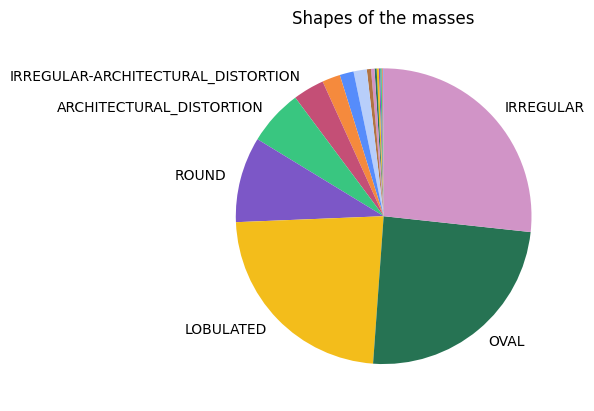

In [11]:
to_plot = df_mass_train.groupby(['mass shape']).count().sort_values(['breast_density'])
labels = to_plot.index.to_list()
for i in range(len(labels)):
    if to_plot.loc[labels[i]]['breast_density'] < 30:
        labels[i] = ""

plt.pie(to_plot.iloc[:, 1], labels = labels, startangle=90)
plt.title("Shapes of the masses")
plt.show()

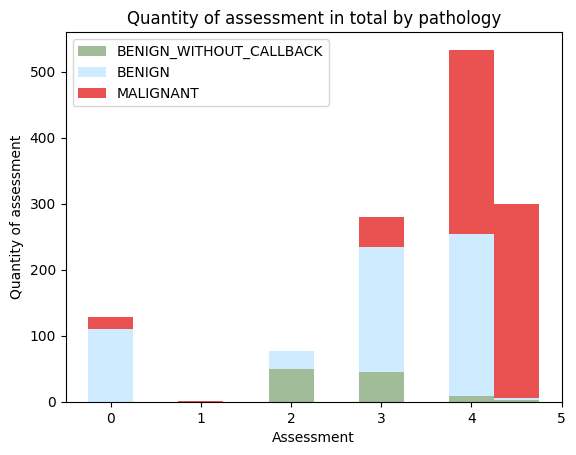

In [12]:
data_0 = df_mass_train[df_mass_train["pathology"] == "BENIGN_WITHOUT_CALLBACK"]["assessment"]
data_1 = df_mass_train[df_mass_train["pathology"] == "BENIGN"]["assessment"]
data_2 = df_mass_train[df_mass_train["pathology"] == "MALIGNANT"]["assessment"]

plt.hist(
    [data_0, data_1, data_2],
    stacked=True,
    color=["#A1BC98", "#CFEBFF", "#EA5252"],
    label=["BENIGN_WITHOUT_CALLBACK", "BENIGN", "MALIGNANT"],
    align="left",
)
plt.xlabel("Assessment")
plt.ylabel("Quantity of assessment")
plt.title("Quantity of assessment in total by pathology")
plt.legend()
plt.show()

In [13]:
df_data2 = pd.DataFrame(data_2)
df_data2[df_data2["assessment"] == 0].count()

assessment    19
dtype: int64

Sometimes, the assessment of the doctor has been really wrong since 19 assessment were wrong. It is not big but a 0 in assessment can not be trust. Even more knowing than no benign without callback can be found in the assessment 0.

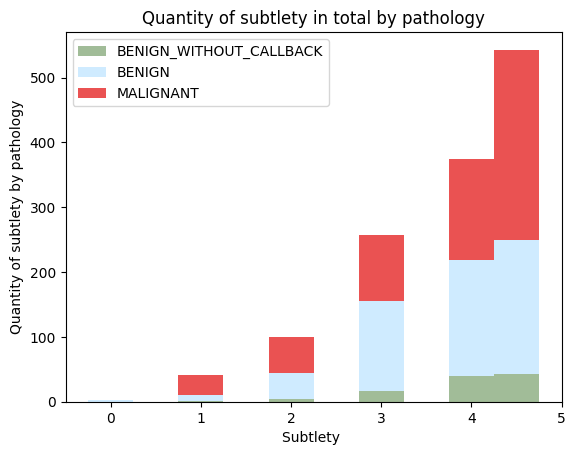

In [14]:
data_0 = df_mass_train[df_mass_train["pathology"] == "BENIGN_WITHOUT_CALLBACK"]["subtlety"]
data_1 = df_mass_train[df_mass_train["pathology"] == "BENIGN"]["subtlety"]
data_2 = df_mass_train[df_mass_train["pathology"] == "MALIGNANT"]["subtlety"]

plt.hist(
    [data_0, data_1, data_2],
    stacked=True,
    color=["#A1BC98", "#CFEBFF", "#EA5252"],
    label=["BENIGN_WITHOUT_CALLBACK", "BENIGN", "MALIGNANT"],
    align="left",
)
plt.xlabel("Subtlety ")
plt.ylabel("Quantity of subtlety by pathology")
plt.title("Quantity of subtlety in total by pathology")
plt.legend()
plt.show()

# Models

## Second one, preparation

We will create a custm CNN. For this one, we want to test how good the model can be with only the images

In [15]:
# Getting only the target variable and the path of the simple image
df_second_model = pd.concat([df_mass_train, df_mass_test])[['patient_id', 'left or right breast','pathology', 'image file path']]
df_second_model

,patient_id,left or right breast,pathology,image file path
0,P_00001,LEFT,MALIGNANT,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...
1,P_00001,LEFT,MALIGNANT,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...
2,P_00004,LEFT,BENIGN,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...
3,P_00004,LEFT,BENIGN,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...
4,P_00004,RIGHT,BENIGN,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...
...,...,...,...,...
373,P_01825,RIGHT,BENIGN_WITHOUT_CALLBACK,Mass-Test_P_01825_RIGHT_MLO/1.3.6.1.4.1.9590.1...
374,P_01833,RIGHT,MALIGNANT,Mass-Test_P_01833_RIGHT_MLO/1.3.6.1.4.1.9590.1...
375,P_01865,LEFT,MALIGNANT,Mass-Test_P_01865_LEFT_MLO/1.3.6.1.4.1.9590.10...
376,P_01912,RIGHT,MALIGNANT,Mass-Test_P_01912_RIGHT_CC/1.3.6.1.4.1.9590.10...


In [16]:
df_second_model_no_duplicate = df_second_model.drop_duplicates(subset=['image file path'])
df_second_model_no_duplicate

,patient_id,left or right breast,pathology,image file path
0,P_00001,LEFT,MALIGNANT,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...
1,P_00001,LEFT,MALIGNANT,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...
2,P_00004,LEFT,BENIGN,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...
3,P_00004,LEFT,BENIGN,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...
4,P_00004,RIGHT,BENIGN,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...
...,...,...,...,...
373,P_01825,RIGHT,BENIGN_WITHOUT_CALLBACK,Mass-Test_P_01825_RIGHT_MLO/1.3.6.1.4.1.9590.1...
374,P_01833,RIGHT,MALIGNANT,Mass-Test_P_01833_RIGHT_MLO/1.3.6.1.4.1.9590.1...
375,P_01865,LEFT,MALIGNANT,Mass-Test_P_01865_LEFT_MLO/1.3.6.1.4.1.9590.10...
376,P_01912,RIGHT,MALIGNANT,Mass-Test_P_01912_RIGHT_CC/1.3.6.1.4.1.9590.10...


In [17]:
df_second_model_with_type_of_breast = df_second_model_no_duplicate
df_second_model_with_type_of_breast['id'] = df_second_model_with_type_of_breast['patient_id'] + df_second_model_with_type_of_breast['left or right breast']
df_second_model_with_type_of_breast = df_second_model_with_type_of_breast[['id', 'pathology', 'image file path']]
df_second_model_with_type_of_breast

,id,pathology,image file path
0,P_00001LEFT,MALIGNANT,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...
1,P_00001LEFT,MALIGNANT,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...
2,P_00004LEFT,BENIGN,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...
3,P_00004LEFT,BENIGN,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...
4,P_00004RIGHT,BENIGN,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...
...,...,...,...
373,P_01825RIGHT,BENIGN_WITHOUT_CALLBACK,Mass-Test_P_01825_RIGHT_MLO/1.3.6.1.4.1.9590.1...
374,P_01833RIGHT,MALIGNANT,Mass-Test_P_01833_RIGHT_MLO/1.3.6.1.4.1.9590.1...
375,P_01865LEFT,MALIGNANT,Mass-Test_P_01865_LEFT_MLO/1.3.6.1.4.1.9590.10...
376,P_01912RIGHT,MALIGNANT,Mass-Test_P_01912_RIGHT_CC/1.3.6.1.4.1.9590.10...


In [18]:
df_data = pd.DataFrame(df_second_model_with_type_of_breast.groupby(['id']).count()['pathology'])
df_data

,pathology
id,
P_00001LEFT,2
P_00004LEFT,2
P_00004RIGHT,1
P_00009RIGHT,2
P_00015LEFT,1
...,...
P_01981RIGHT,2
P_01983LEFT,1
P_02033RIGHT,2


We can see that we now have a dataframe with no duplicate on the images and separating the breast of one patient. Meaning we can now use multiple images of one breast to determine if there is a cancer instead of doing it one by one.

We will build a CNN model which uses two images. This data would help the model be able to detect beter the cancer. When only one image exists, we will duplicate it.

In [19]:
df_second_model_with_type_of_breast

,id,pathology,image file path
0,P_00001LEFT,MALIGNANT,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...
1,P_00001LEFT,MALIGNANT,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...
2,P_00004LEFT,BENIGN,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...
3,P_00004LEFT,BENIGN,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...
4,P_00004RIGHT,BENIGN,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...
...,...,...,...
373,P_01825RIGHT,BENIGN_WITHOUT_CALLBACK,Mass-Test_P_01825_RIGHT_MLO/1.3.6.1.4.1.9590.1...
374,P_01833RIGHT,MALIGNANT,Mass-Test_P_01833_RIGHT_MLO/1.3.6.1.4.1.9590.1...
375,P_01865LEFT,MALIGNANT,Mass-Test_P_01865_LEFT_MLO/1.3.6.1.4.1.9590.10...
376,P_01912RIGHT,MALIGNANT,Mass-Test_P_01912_RIGHT_CC/1.3.6.1.4.1.9590.10...


In [20]:
df_second_model_with_type_of_breast["img_num"] = "image" + (df_second_model_with_type_of_breast.groupby("id").cumcount() + 1).astype(str)

df_second_model_cleaned = (
    df_second_model_with_type_of_breast.pivot(index=["id", "pathology"], columns="img_num", values="image file path")
    .reset_index()
    .rename_axis(None, axis=1)
)
df_second_model_cleaned['image1'] = df_second_model_cleaned['image1'].fillna(df_second_model_cleaned['image2'])
df_second_model_cleaned['image2'] = df_second_model_cleaned['image2'].fillna(df_second_model_cleaned['image1'])
df_second_model_cleaned

,id,pathology,image1,image2
0,P_00001LEFT,MALIGNANT,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...
1,P_00004LEFT,BENIGN,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...
2,P_00004RIGHT,BENIGN,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...
3,P_00009RIGHT,MALIGNANT,Mass-Training_P_00009_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_00009_RIGHT_MLO/1.3.6.1.4.1.95...
4,P_00015LEFT,MALIGNANT,Mass-Training_P_00015_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00015_LEFT_MLO/1.3.6.1.4.1.959...
...,...,...,...,...
929,P_01981RIGHT,MALIGNANT,Mass-Training_P_01981_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_01981_RIGHT_MLO/1.3.6.1.4.1.95...
930,P_01983LEFT,MALIGNANT,Mass-Training_P_01983_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_01983_LEFT_MLO/1.3.6.1.4.1.959...
931,P_02033RIGHT,MALIGNANT,Mass-Training_P_02033_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_02033_RIGHT_MLO/1.3.6.1.4.1.95...
932,P_02079RIGHT,MALIGNANT,Mass-Training_P_02079_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_02079_RIGHT_MLO/1.3.6.1.4.1.95...


Now our dataset is clean, with 2 images per breast let it be two different picture or a copy

# Start of second model

In [21]:
df_second_model_cleaned = df_second_model_cleaned[['pathology', 'image1', 'image2']]

In [22]:
df_second_model_cleaned['pathology'] = df_second_model_cleaned['pathology'].replace("BENIGN_WITHOUT_CALLBACK", "BENIGN")
df_second_model_cleaned

,pathology,image1,image2
0,MALIGNANT,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...
1,BENIGN,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...
2,BENIGN,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...
3,MALIGNANT,Mass-Training_P_00009_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_00009_RIGHT_MLO/1.3.6.1.4.1.95...
4,MALIGNANT,Mass-Training_P_00015_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00015_LEFT_MLO/1.3.6.1.4.1.959...
...,...,...,...
929,MALIGNANT,Mass-Training_P_01981_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_01981_RIGHT_MLO/1.3.6.1.4.1.95...
930,MALIGNANT,Mass-Training_P_01983_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_01983_LEFT_MLO/1.3.6.1.4.1.959...
931,MALIGNANT,Mass-Training_P_02033_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_02033_RIGHT_MLO/1.3.6.1.4.1.95...
932,MALIGNANT,Mass-Training_P_02079_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_02079_RIGHT_MLO/1.3.6.1.4.1.95...


In [23]:
# We encode the pathology
le = LabelEncoder()
df_second_model_cleaned['pathology'] = pd.DataFrame(le.fit_transform(df_second_model_cleaned['pathology'].to_numpy()))
df_second_model_cleaned

,pathology,image1,image2
0,1,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...
1,0,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...
2,0,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...
3,1,Mass-Training_P_00009_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_00009_RIGHT_MLO/1.3.6.1.4.1.95...
4,1,Mass-Training_P_00015_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00015_LEFT_MLO/1.3.6.1.4.1.959...
...,...,...,...
929,1,Mass-Training_P_01981_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_01981_RIGHT_MLO/1.3.6.1.4.1.95...
930,1,Mass-Training_P_01983_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_01983_LEFT_MLO/1.3.6.1.4.1.959...
931,1,Mass-Training_P_02033_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_02033_RIGHT_MLO/1.3.6.1.4.1.95...
932,1,Mass-Training_P_02079_RIGHT_CC/1.3.6.1.4.1.959...,Mass-Training_P_02079_RIGHT_MLO/1.3.6.1.4.1.95...


In [24]:
# we switch to two numpy arrays
y = df_second_model_cleaned['pathology'].to_numpy()
x1 = []
index = 0
for path in df_second_model_cleaned['image1']:
    if index%50 == 0:
        print(index)
    index+=1
    try :
        x1.append(get_full_image(path))
    except:
        print("error")
        x1.append(np.array([]))

x2 = []
index = 0
for path in df_second_model_cleaned['image2']:
    if index%50 == 0:
        print(index)
    index+=1
    try :
        x2.append(get_full_image(path))
    except:
        print("error")
        x2.append(np.array([]))
x1 = np.array(x1)
x2 = np.array(x2)
x = np.concat((x1, x2), axis=1)

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900


In [25]:
x.shape

(934, 1024, 512)

In [26]:
x = x.reshape(-1, 1, 1024, 512)

In [27]:
x.shape

(934, 1, 1024, 512)

In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

In [29]:
x_train.shape

(625, 1, 1024, 512)

In [30]:
import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

In [31]:
# The type float32 is mandatory for the torch model
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Creation of what is called a dataset : a fusion of x and y for torch
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

# Creation of dataloaders : What control the flow of data in the gpu. It controls the batch flow to avoid the gpu to drown on to much images. It also controls the loading of data into the gpu, when a batch is processed, the next is loaded into the memory for a quick access by the gpu.
batch_size = 16
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False) # No need to shuffle the test

In [42]:
class CNN(nn.Module):
    def __init__(self):
        """
        Building blocks of convolutional neural network.
       """
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1,  out_channels=64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)   # 1024x512 -> 512x256
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)   # 512x256 -> 256x128
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)   # 256x128 -> 128x64
        self.relu  = nn.ReLU()
        self.fc    = nn.Linear(128 * 64 * 128, 1) # 128x64x128 = dim of result image * number of filter, 1 is the out feature

    def forward(self, x):
        """
        Define the forward pass of the neural network.

        Parameters:
            x: Input tensor.

        Returns:
            torch.Tensor
                The output tensor after passing through the network.
       """
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool1(x)
        x = self.relu(self.conv3(x))
        x = self.pool2(x)
        x = self.relu(self.conv4(x))
        x = self.pool3(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


In [43]:
# Use the gpu if possible
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN().to(device)
print(model)

AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [40]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [41]:
num_epochs=10
for epoch in range(num_epochs):
    # Iterate over training batches
    print(f"Epoch [{epoch + 1}/{num_epochs}]")
    # tqdm here just gives a progress bar. Being fancy ✨
    for batch_index, (data, targets) in enumerate(tqdm(train_loader)):
        # send data to the gpu (or cpu if we don't have cuda)
        data = data.to(device)
        targets = targets.to(device).unsqueeze(1).float()

        # Forward pass and compute of the loss
        scores = model(data)
        loss = criterion(scores, targets)

        # reset gradient from the last batch (no reseting would cause problem since Pytorch keeps in memory the gradient from last batch. Doing it without batches would make this reset useless)
        optimizer.zero_grad()

        # Backward phase + adjusting of the weights
        loss.backward()
        optimizer.step()

Epoch [1/10]


  0%|          | 0/40 [03:08<?, ?it/s]

KeyboardInterrupt

